# 학습된 모델 저장

- 학습이 완료된 모델을 파일로 저장하여, 이후 추가 학습이나 예측 서비스에 사용할 수 있도록 한다.
- 파이토치(PyTorch)는 **모델의 파라미터만 저장**하는 방법과 **모델의 구조와 파라미터를 모두 저장**하는 두 가지 방식을 제공한다.
- 저장 함수
  - `torch.save(저장할 객체, 저장 경로)`
- 보통 저장 파일의 확장자는 `.pt`나 `.pth`를 사용한다.

## 모델 전체 저장 및 불러오기

- 저장하기
  - `torch.save(model, 저장 경로)`
- 불러오기
  - `load_model = torch.load(저장 경로)`
- 모델 저장 시 **피클(pickle)**을 사용해 직렬화되므로, 모델을 불러오는 실행 환경에도 저장할 때 사용한 클래스 정의가 필요하다.


## 모델의 파라미터만 저장

-   모델을 구성하는 파라미터만 저장한다.
-   모델의 구조는 저장하지 않기 때문에 불러올 때 **모델을 먼저 생성하고 생성한 모델에 불러온 파라미터를 덮어씌운다.**
-   모델의 파라미터는 **state_dict** 형식으로 저장한다.

### state_dict

-   모델의 파라미터 Tensor들을 레이어 단위별로 나누어 저장한 Ordered Dictionary (OrderedDict)
-   `모델객체.state_dict()` 메소드를 이용해 조회한다.
-   모델의 state_dict을 조회 후 저장한다.
    -   `torch.save(model.state_dict(), "저장경로")`
-   생성된 모델에 읽어온 state_dict를 덮어씌운다.
    -   `new_model.load_state_dict(torch.load("state_dict저장경로"))`


## Checkpoint 저장 및 불러오기

- 학습이 끝나지 않은 모델을 저장하고, 나중에 이어서 학습시키려면 모델의 구조와 파라미터뿐만 아니라 optimizer, loss 함수 등 학습에 필요한 객체들도 함께 저장해야 한다.
- 딕셔너리(Dictionary)에 저장하려는 값들을 key-value 쌍으로 구성하여 `torch.save()`를 이용해 저장한다.

```python
# 저장
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': train_loss
}, "저장경로")

# 불러오기
model = MyModel()
optimizer = optim.Adam(model.parameters())

# 불러온 checkpoint를 이용해 이전 학습 상태 복원
checkpoint = torch.load("저장경로")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
```

In [1]:
# 간단한 모델 정의
import torch
import torch.nn as nn

class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(3, 4) # 3 X 4 + 4 
        self.lr2 = nn.Linear(4, 2)
        self.relu = nn.ReLU() # activation함수->파라미터가 없는 단순 계산함수. relu(X) = max(X, 0)
    def forward(self, X):
        X = self.lr1(X)
        X = self.relu(X)
        X = self.lr2(X)
        return X

In [2]:
# 모델 생성성
model = MyModel()
model

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

In [3]:
################################################
#  모델에 Layer들을 조회. 모델.instance변수명
################################################
lr_layer = model.lr1
lr_layer

Linear(in_features=3, out_features=4, bias=True)

In [4]:
################################################
#  Layer의 파라미터(weight/bias) 조회
################################################
lr1_weight = lr_layer.weight
lr1_bias = lr_layer.bias

In [5]:
lr1_weight

Parameter containing:
tensor([[-0.0972,  0.4401, -0.1200],
        [ 0.5543, -0.1962,  0.4837],
        [-0.5064, -0.0235,  0.4192],
        [ 0.2031, -0.2793,  0.2127]], requires_grad=True)

In [6]:
lr1_bias

Parameter containing:
tensor([-0.0138, -0.2787,  0.3550, -0.0407], requires_grad=True)

In [7]:
import os
os.makedirs("saved_models", exist_ok=True)

In [8]:
################################################
#  모델을 저장
################################################
torch.save(model, "saved_models/my_model.pt")

In [9]:
################################################
#  저장된 모델 Load
################################################
load_model = torch.load("saved_models/my_model.pt", weights_only=False)

In [10]:
load_model

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

In [11]:
######################################################
# 모델의 파라미터들(weight들, bias들)만 저장/불러오기
######################################################
state_dict = model.state_dict()
state_dict

OrderedDict([('lr1.weight',
              tensor([[-0.0972,  0.4401, -0.1200],
                      [ 0.5543, -0.1962,  0.4837],
                      [-0.5064, -0.0235,  0.4192],
                      [ 0.2031, -0.2793,  0.2127]])),
             ('lr1.bias', tensor([-0.0138, -0.2787,  0.3550, -0.0407])),
             ('lr2.weight',
              tensor([[ 0.1625, -0.1073,  0.2268,  0.1323],
                      [-0.2650,  0.1477,  0.4797,  0.1684]])),
             ('lr2.bias', tensor([-0.1348,  0.4934]))])

In [12]:
state_dict.keys()

odict_keys(['lr1.weight', 'lr1.bias', 'lr2.weight', 'lr2.bias'])

In [13]:
###################
# state_dict 저장
################### 

torch.save(state_dict, "saved_models/my_model_parameter.pt") # weight_only = True (default)

In [ ]:
#####################
# state_dict load
#####################
sd = torch.load("saved_models/my_model_parameter.pt") # weight_only = True (default)

In [15]:
# load한 state_dict를 모델 파라미터에 적용(덮어 씌운다.)
new_model = MyModel()
new_model.state_dict()

OrderedDict([('lr1.weight',
              tensor([[ 0.1999,  0.0859, -0.2595],
                      [-0.0267, -0.1198,  0.5360],
                      [-0.4837,  0.4942, -0.4605],
                      [-0.0514, -0.2275,  0.4986]])),
             ('lr1.bias', tensor([-0.5225, -0.2183, -0.3097, -0.0693])),
             ('lr2.weight',
              tensor([[-0.0773, -0.3848,  0.0868,  0.1481],
                      [ 0.2666,  0.3356, -0.3419,  0.4087]])),
             ('lr2.bias', tensor([0.2941, 0.0033]))])

In [16]:
new_model.load_state_dict(sd)

<All keys matched successfully>

In [17]:
new_model.state_dict()

OrderedDict([('lr1.weight',
              tensor([[-0.0972,  0.4401, -0.1200],
                      [ 0.5543, -0.1962,  0.4837],
                      [-0.5064, -0.0235,  0.4192],
                      [ 0.2031, -0.2793,  0.2127]])),
             ('lr1.bias', tensor([-0.0138, -0.2787,  0.3550, -0.0407])),
             ('lr2.weight',
              tensor([[ 0.1625, -0.1073,  0.2268,  0.1323],
                      [-0.2650,  0.1477,  0.4797,  0.1684]])),
             ('lr2.bias', tensor([-0.1348,  0.4934]))])

In [ ]:
# torchinfo 패키지 설치: 파이토치 모델 구조를 조사해주는 패키지.
# !pip install torchinfo

In [18]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
MyModel                                  --
├─Linear: 1-1                            16
├─Linear: 1-2                            10
├─ReLU: 1-3                              --
Total params: 26
Trainable params: 26
Non-trainable params: 0

In [19]:
# input data 의 shape을 지정하면 각 Layer의 output shape을 출력한다.
summary(model, (100, 3))

# p = model(X) X의 shape

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [100, 2]                  --
├─Linear: 1-1                            [100, 4]                  16
├─ReLU: 1-2                              [100, 4]                  --
├─Linear: 1-3                            [100, 2]                  10
Total params: 26
Trainable params: 26
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01

# 문제 유형별 MLP 네트워크
- 해결하려는 문제 유형에 따라 출력 Layer의 구조가 바뀐다.
- 딥러닝 구조에서 **Feature를 추출하는 Layer 들을 Backbone** 이라고 하고 **추론하는 Layer들을 Head** 라고 한다. 


> - MLP(Multi Layer Perceptron), DNN(Deep Neural Network), ANN(Artificial Neural Network)
>     -   Fully Connected Layer(nn.Linear)로 구성된 딥러닝 모델
>     -   input feature들 모두에 대응하는 weight들(가중치)을 사용한다.
> 

## Boston Housing Dataset - **Regression(회귀) 문제**

보스턴 주택가격 dataset은 다음과 같은 속성을 바탕으로 해당 타운 주택 가격의 중앙값을 예측하는 문제.

-   CRIM: 범죄율
-   ZN: 25,000 평방피트당 주거지역 비율
-   INDUS: 비소매 상업지구 비율
-   CHAS: 찰스강에 인접해 있는지 여부(인접:1, 아니면:0)
-   NOX: 일산화질소 농도(단위: 0.1ppm)
-   RM: 주택당 방의 수
-   AGE: 1940년 이전에 건설된 주택의 비율
-   DIS: 5개의 보스턴 직업고용센터와의 거리(가중 평균)
-   RAD: 고속도로 접근성
-   TAX: 재산세율
-   PTRATIO: 학생/교사 비율
-   B: 흑인 비율
-   LSTAT: 하위 계층 비율
    <br><br>
-   **Target**
    -   MEDV: 타운의 주택가격 중앙값(단위: 1,000달러)


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [3]:
boston = pd.read_csv('./boston_dataset.csv')
X_boston = boston.drop(columns= 'MEDV').values
y_boston = boston['MEDV'].values.reshape(-1, 1) 
#(506, ) -> (506, 1) << dummie추가 pytorch의 y값에 맞춰주는것.

X_boston.shape, y_boston.shape

((506, 13), (506, 1))

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_boston, y_boston, test_size= 0.2, random_state= 42
)

In [5]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Dataset 생성
trainset_boston = TensorDataset(
    torch.tensor(X_train_scaled, dtype = torch.float32),
    torch.tensor(y_train, dtype = torch.float32) # dtype은 모델의 dtype인 float32로 바꿔준다.
)
testset_boston = TensorDataset(
    torch.tensor(X_test_scaled, dtype = torch.float32),
    torch.tensor(y_test, dtype= torch.float32)
)

len(trainset_boston), len(testset_boston)

(404, 102)

In [7]:
#DataLoader
train_loader_boston = DataLoader(
    trainset_boston, batch_size = 202, shuffle= True, drop_last= True
)
test_loader_boston = DataLoader(
    testset_boston, batch_size= 102
)

len(train_loader_boston), len(test_loader_boston)

(2, 1)

In [8]:
# 모델 class 정의
## 회귀 - output Layer의 unit 수: y의 개수 (K, 1)
##      - output Layer의 Activation 함수 - 보통은 주지 않는다.

class BostonModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(13, 32) # input Layer 처리
        self.lr2 = nn.Linear(32, 16)

        # output Layer
        self.lr3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        
    def forward(self, X):
        out = self.lr1(X)
        out = self.relu(out)
        out = self.lr2(out)
        out = self.relu(out)
        output = self.lr3(out)

        return output



In [9]:
# 학습

## 모델 생성

boston_model = BostonModel().to(device)
summary(boston_model, (100,13), device= device)


Layer (type:depth-idx)                   Output Shape              Param #
BostonModel                              [100, 1]                  --
├─Linear: 1-1                            [100, 32]                 448
├─ReLU: 1-2                              [100, 32]                 --
├─Linear: 1-3                            [100, 16]                 528
├─ReLU: 1-4                              [100, 16]                 --
├─Linear: 1-5                            [100, 1]                  17
Total params: 993
Trainable params: 993
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.00
Estimated Total Size (MB): 0.05

In [12]:
## 손실함수 - 회귀: MSELoss
loss_fn = nn.MSELoss()
## 옵티마이저
optimizer = torch.optim.Adam(boston_model.parameters(), lr = 0.001) # 모델의 파라미터, learning_rate

In [ ]:
epochs = 1000

train_loss_list = []
val_loss_list = []

for epoch in range(epochs):
    ##################################
    # 학습
    ##################################
    boston_model.train()
    train_loss = 0.0
    for X, y in train_loader_boston:
        # 1. X, y를 device로 이동
        X, y = X.to(device), y.to(device)
        # 2. 추론
        pred = boston_model(X)
        # 3. 오차계산
        loss = loss_fn(pred, y)
        # 4. gradeint 계산
        loss.backward()
        # 5. 파라미터 업데이트
        optimizer.step()
        # 6. 파라미터의 gradeint 초기화
        optimizer.zero_grad()

        train_loss += loss.item()

    # 1 epoch loss
    train_loss = train_loss / len(train_loader_boston)

    ##################################
    # 검증 - 1 epoch 학습한 것에 대한 검증
    ##################################
    boston_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in test_loader_boston:
            # 1. X, y를 device로 이동
            X_val, y_val = X_val.to(device), y_val.to(device)
            # 2. 추론
            pred_val = boston_model(X_val)
            # 3. 검증 - 평가지표 계산 (회귀:MSE)
            val_loss += loss_fn(pred_val, y_val).item()

    val_loss /= len(test_loader_boston) # val_loss 평균을 저장.

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    if epoch % 100 == 0 or epoch == (epochs-1):
        print(f"{epoch+1}/{epochs} train loss: {train_loss}, val_loss: {val_loss}")
        

1/1000 train loss: 613.3345031738281, val_loss: 540.9564208984375
101/1000 train loss: 90.00829696655273, val_loss: 72.43255615234375
201/1000 train loss: 23.35958766937256, val_loss: 24.529756546020508
301/1000 train loss: 16.49254035949707, val_loss: 18.248817443847656
401/1000 train loss: 12.334943771362305, val_loss: 14.50658130645752
501/1000 train loss: 10.457967758178711, val_loss: 12.815935134887695
601/1000 train loss: 9.35098123550415, val_loss: 12.130915641784668
701/1000 train loss: 8.496201038360596, val_loss: 11.694984436035156
801/1000 train loss: 7.829716682434082, val_loss: 11.245075225830078
901/1000 train loss: 7.2597668170928955, val_loss: 10.833065032958984
1000/1000 train loss: 6.728457450866699, val_loss: 10.413518905639648


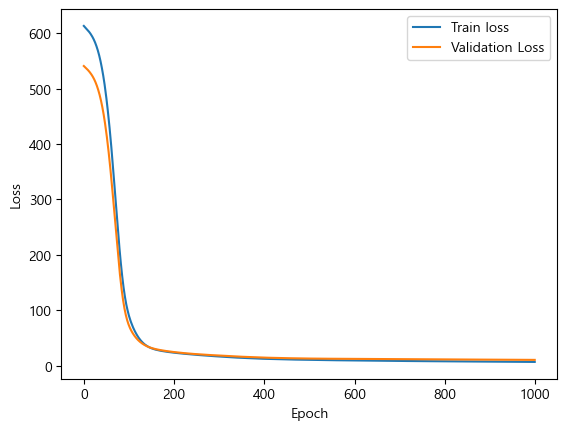

In [14]:
plt.plot(range(epochs), train_loss_list, label= "Train loss")
plt.plot(range(epochs), val_loss_list, label= 'Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
# Testset으로 최종 검증. << 까지가 원래 단계
boston_model.eval()
test_loss = 0.0
with torch.no_grad():
    for X_test, y_test in test_loader_boston:
        # 1. X, y를 device로 이동
        X_test, y_test = X_test.to(device), y_test.to(device)
        # 2. 추론
        pred_test = boston_model(X_test)
        # 3. 검증 - 평가지표 계산 (회귀:MSE)
        test_loss += loss_fn(pred_test, y_test).item()

test_loss /= len(test_loader_boston) #testl_loss 평균을 저장.

print("최종 평가: ", test_loss)

최종 평가:  10.413518905639648


In [ ]:
@torch.no_grad() # 이 함수는 grad를 계산할 필요가 없는 함수임을 선언. with torch.no_grad() 대신
def test(model, dataloader, device='cpu'):
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_test, y_test in dataloader:
            # 1. X, y를 device로 이동
            X_test, y_test = X_test.to(device), y_test.to(device)
            # 2. 추론
            pred_test = model(X_test)
            # 3. 검증 - 평가지표 계산 (회귀:MSE)
            test_loss += loss_fn(pred_test, y_test).item()

    test_loss /= len(dataloader)

    print("최종 평가: ", test_loss)

In [18]:
test(boston_model, train_loader_boston)

최종 평가:  6.720137596130371


In [19]:
# 모델 저장.
## 파라미터만 저장, 모델 전체를 저장.
saved_path = "models/boston_model.pt"
torch.save(boston_model, saved_path)

In [ ]:
# 모델 로드
load_boston_model = torch.load(saved_path, weights_only= False)
load_boston_model = load_boston_model.to(device)
summary(load_boston_model, (100, 13), device= device)

Layer (type:depth-idx)                   Output Shape              Param #
BostonModel                              [100, 1]                  --
├─Linear: 1-1                            [100, 32]                 448
├─ReLU: 1-2                              [100, 32]                 --
├─Linear: 1-3                            [100, 16]                 528
├─ReLU: 1-4                              [100, 16]                 --
├─Linear: 1-5                            [100, 1]                  17
Total params: 993
Trainable params: 993
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.00
Estimated Total Size (MB): 0.05

In [21]:
test(load_boston_model, test_loader_boston)

최종 평가:  10.413518905639648


## 분류 (Classification)

### Fashion MNIST Dataset - **다중분류(Multi-Class Classification) 문제**

10개의 범주(category)와 70,000개의 흑백 이미지로 구성된 [패션 MNIST](https://github.com/zalandoresearch/fashion-mnist) 데이터셋.
이미지는 해상도(28x28 픽셀)가 낮고 다음처럼 개별 의류 품목을 나타낸다:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>그림</b> <a href="https://github.com/zalandoresearch/fashion-mnist">패션-MNIST 샘플</a> (Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

- **Feature**이미지는 28x28 크기이며 Gray scale이다.
- **Target**은 총 10개의 class로 구성되어 있으며 각 class의 class 이름은 다음과 같다.

| 레이블 | 클래스       |
|--------|--------------|
| 0      | T-shirt/top |
| 1      | Trousers    |
| 2      | Pullover    |
| 3      | Dress       |
| 4      | Coat        |
| 5      | Sandal      |
| 6      | Shirt       |
| 7      | Sneaker     |
| 8      | Bag         |
| 9      | Ankle boot  |

> #### 학습 도중 모델 저장
>
> - 학습 도중 가장 좋은 성능을 보이는 모델이 나올 수 있다.
> - 학습 도중 모델을 저장하는 방법
>   1. 각 에폭이 끝날 때 마다 모델을 저장한다.
>   2. 한 에폭 학습 후 성능 개선이 있으면 모델을 저장하여 가장 성능 좋은 모델만 저장되도록 한다.
>      - 최고 성능 점수(best score)와 현재 에폭의 성능을 비교하여, 성능이 개선되었을 경우 모델을 저장(덮어쓰기)한다.
>
> #### 조기 종료(Early Stopping)
>
> - 학습 도중 성능 개선이 나타나지 않으면, 중간에 학습을 종료하도록 구현한다.
> - 에폭 수를 충분히 길게 설정한 뒤, 특정 횟수 동안 성능 개선이 없으면 학습을 조기 종료하도록 구현한다.


In [22]:
# augmentation 적용 버전

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import random
import numpy as np

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

train_transform = transforms.Compose([
    transforms.RandomRotation(8), # 회전 10도 랜덤
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)), # 위치 살짝 이동
    transforms.ToTensor()
])

valid_transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_aug = datasets.FashionMNIST( # 훈련용 데이터를 변형하기 위한 데이터와 valid용 원본 데이터 두개 로드
    root = "./data",
    train=True,
    download=True, # 데이터가 없으면 자동 다운로드 하라는 코드.
    transform=train_transform
)

full_train_plain = datasets.FashionMNIST(
    root= "./data",
    train=True,
    download=True,
    transform=valid_transform
)

train_size = 48000 # 4:1비율 훈련, 검증 데이터 나누기
valid_size = 12000

g = torch.Generator().manual_seed(42)
indices = torch.randperm(len(full_train_aug), generator=g).tolist() # randperm: 데이터 인덱스를 랜덤하게 섞는 도구 / full_train_aug는 60000개의 전체데이터를 넣기위해 / tolist는 텐서데이터를 파이썬 리스트로 변환해주는것
                                                       # 리스트로 변환해주는 이유는 Subset이 list를 더 편하게 받기 때문이다. (관례적으로 사용함)
train_indices = indices[:train_size] # 앞 48000개 train
valid_indices = indices[train_size:] # 뒤 12000개 valid / 데이터를 랜덤하게 train, valid 분리

train_dataset = Subset(full_train_aug, train_indices) # Subset(데이터셋, 인덱스리스트) : 전체 데이터 중에서 특정 번호(인덱스)들만 골라서 새로운 데이터셋을 생성해라.
valid_dataset = Subset(full_train_plain, valid_indices) # augmentation이 적용된 데이터에서 train_indices에 해당되는 것만 사용해라. valid도 마찬가지(plain이 적용된 데이터에서 valid_indices에 해당하는 것만 사용)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle= True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle= False)

import torch.nn as nn

class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential( # 특징 추출 (Conv 영역)
            nn.Conv2d(1, 32, kernel_size=3, padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32,32, kernel_size=3, padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), #28 -> 14

            nn.Conv2d(32,64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), #14 -> 7

            nn.Conv2d(64,128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 7 -> 3
        )

        self.classifier = nn.Sequential( # 분류 (Linear 영역)
            nn.Flatten(), # Linear가 원하는 입력 형태는 2차원 입력(batch_size, feature 수) 예 (64개의 데이터, 1152개의 특징) 인데 flatten(=x.view(x.size(0),-1))같은 평면화 하지않으면 (64, 128, 3, 3) 이렇게 생김
                          # flatten은 모양을 바꾸는 작업 이 밑의 Linear는 데이터를 학습하는 작업
            nn.Linear(128 * 3 * 3, 256), # 1152개의 특징 -> 256개의 중요한 특징으로 압축
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
        
# 모델/손실함수/옵티마이저 준비
model = BetterCNN() # 모델 생성

criterion = nn.CrossEntropyLoss() # Cross = 교차 / Entropy = 정보량(불확실성) / Loss = 손실(틀린 정도) / 예측과 정답이 얼마나 다른지 계산하는 함수
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001) # optimizer = 최적화 도구 / 틀린만큼 모델을 어떻게 고칠지 결정
                                                            # Adam = Adaptive Moment Estimation 똑똑하게 가중치를 수정해주는 알고리즘
                                                            # model.parameters() = 모델 안의 모든 가중치(weight) Ex) Conv, Linear
                                                            # lr = Learning rate / 얼마나 크게 수정시킬지 / 너무 크면 왔다갔다 폭발, 너무작으면 너무느려서 거의안배움

# 학습 코드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU or CPU Mac은 NVIDIA CUDA를 지원안해서 CPU
model = model.to(device) # 모델을 CPU에 적용시키는 작업 / 데이터와 모델은 같은 장치에 있어야함

epochs = 20 # 반복 횟수 / 훈련 데이터 전체를 한바퀴 다보는게 1 epoch
best_acc = 0 # 최고 좋은 epoch를 찾는 변수
patience = 3
counter = 0

for epoch in range(epochs): # epoch 횟수만큼 학습 반복
    model.train() # 모델을 학습모드로 전환 training
    train_loss = 0 # epoch동안 손실을 누적해서 기록하기 위한 변수

    for images, labels in train_loader: # train 데이터를 batch단위로 하나씩 꺼내오기
        images, labels = images.to(device), labels.to(device) # 데이터들도 model과 같은 디바이스로 옮겨주기

        optimizer.zero_grad() # 이전 batch에서 계산된 기울기를 초기화 / Pytorch는 기울기를 계속 누적하는데 초기화를 안하면 이전것과 이번것이 섞여버림 / 이번 batch 기준으로 업데이트
        outputs = model(images) # 모델이 이미지를 보고 예측값 생성 / ex) (64,10).. 64장의 이미지 각 이미지마다 10개의 숫자에 대한 점수가 10개
        loss = criterion(outputs, labels) # 모델 예측이 정답과 얼마나 다른지 계산 / 예를들어 정답이 2인데 모델이 2에 높은점수를 주면 loss가 낮고, 다른수에 높은점수를 주면 loss가 높다.
        loss.backward() # 위에서 계산한 오차를 바탕으로 어떤 가중치를 얼마나 고쳐야 하는지 계산하는 작업 / 틀린 원인을 뒤로 거슬러 올라가며 각 가중치의 책임을 계산 (정답 비교-> 오차 계산-> 뒤로 전달)
        optimizer.step() # 방금 계산한 기울기(gradient)를 이용해 실제로 가중치를 수정 / loss.backward() = 오답 분석, optimizer.step() = 실제 수정

        train_loss += loss.item() # 현재 batch의 loss를 숫자로 꺼내서 변수에 누적 / loss.item()은 tensor형태(파이썬숫자)라서 출력용 숫자로 변형하기위해 .item()을 사용
    avg_train_loss = train_loss / len(train_loader)

    model.eval() # 모델을 평가모드로 전환
    correct = 0 # 검증 데이터에서 맞춘 개수 카운트하려는 변수
    total = 0 # 검증 데이터의 전체 개수 카운트하는 변수

    with torch.no_grad(): # 검증할 때에는 gradient 계산하지 말라는 명령어 / 검증할때에는 학습 안하고 평가만 하니 역전파용 계산이 무쓸모.
        for images, labels in valid_loader: # 검증 데이터도 batch 단위로 꺼내오기 단, 이곳에선 train처럼 학습하지 않고 평가만 함.
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # 검증 데이터에 대해 모델의 예측
            _, predicted = torch.max(outputs, 1) # torch.max(outputs, 1)은 가장 큰값, 그 위치(index)를 반환하는데 우리는 index만 필요하니 앞의 값은 버려줌.
                                                 # 1의 의미는 Pytorch에서 0은 세로방향(행) 1이 가로방향(열)을 의미
                                                 # 코드 의미: 각 행(= 각 이미지)에 대해 가장 큰 값과 그 위치를 찾아라 / 각 행에서 가로방향으로 최대값 찾기 > 열방향으로 움직이며 계산
                                                 # dim = 그 축을 없애면서 연산, dim=1 > 열 방향으로 계산 > 행마다 결과
                                                 # dim=0 > 행 방향으로 계산 > 열마다 결과 / dim은 어느방향으로 훑을지!

            total += labels.size(0) # 이번 batch의 데이터 개수를 total에 더해주기. batch size가 64면 한번에 64추가
            correct += (predicted == labels).sum().item() # 이번 batch에서 맞춘 개수 세기 >> 예측과 정답을 비교해서 .sum()으로 True를 1처럼 세서 계산 후 .item()으로 숫자로 바꿔줌

        accuracy = correct / total # 전체 중에서 맞춘 비율

        if accuracy > best_acc: # best_acc변수에 계속 최고 accuracy를 넣어줌
            best_acc = accuracy 
            torch.save(model.state_dict(), "best_model.pth") # 현재 모델의 학습된 가중치를 파일로 저장, 모델에 학습된 모든 값을 파이썬 객체 파일로 저장하는 함수, .pth는 파일 확장자+저장할 파일이름
                                                             # state_dict는 모델이 학습한 모든 지식(뇌)라고 생각하면 됨. 
            counter = 0 # 카운터 초기화
        else:
            counter += 1 # 최고 accuracy보다 안좋은 accuracy가 나온 횟수를 카운트
        
        if counter >= patience:
            print("Early Stopping!")
            break
        
        # 추후에 파일 불러와서 사용할 때
        # model = BetterCNN()  구조 먼저 만들고
        # model.load_state_dict(torch.load("best_model.pth")) 파일 불러오기
        # model.eval() 시험 모드 시작
        
        print(f"Epoch {epoch+1}/{epochs}, Train loss: {avg_train_loss:.4f}, Valid Accuracy: {accuracy:.4f}") # 현재 epoch의 학습상태 출력

100.0%
100.0%
100.0%
100.0%


Epoch 1/20, Train loss: 0.5048, Valid Accuracy: 0.8811
Epoch 2/20, Train loss: 0.3363, Valid Accuracy: 0.8940
Epoch 3/20, Train loss: 0.2991, Valid Accuracy: 0.9107
Epoch 4/20, Train loss: 0.2750, Valid Accuracy: 0.9125
Epoch 5/20, Train loss: 0.2565, Valid Accuracy: 0.9185
Epoch 6/20, Train loss: 0.2473, Valid Accuracy: 0.9214
Epoch 7/20, Train loss: 0.2308, Valid Accuracy: 0.9231
Epoch 8/20, Train loss: 0.2226, Valid Accuracy: 0.9198
Epoch 9/20, Train loss: 0.2157, Valid Accuracy: 0.9242
Epoch 10/20, Train loss: 0.2085, Valid Accuracy: 0.9274
Epoch 11/20, Train loss: 0.2000, Valid Accuracy: 0.9229
Epoch 12/20, Train loss: 0.1939, Valid Accuracy: 0.9325
Epoch 13/20, Train loss: 0.1877, Valid Accuracy: 0.9339
Epoch 14/20, Train loss: 0.1845, Valid Accuracy: 0.9318
Epoch 15/20, Train loss: 0.1788, Valid Accuracy: 0.9352
Epoch 16/20, Train loss: 0.1761, Valid Accuracy: 0.9343
Epoch 17/20, Train loss: 0.1719, Valid Accuracy: 0.9286
Epoch 18/20, Train loss: 0.1660, Valid Accuracy: 0.9367
E

In [ ]:
# 학습 결과 시각화
import pandas as pd
train_result = pd.DataFrame({
    "train loss": train_loss_list,
    "valid loss": val_loss_list,
    # "val accuracy": val_acc_list
})
train_result.rename(index="Epoch", inplace= True)
train_result.head()

AttributeError: 'function' object has no attribute 'axes'

In [ ]:
train_result[['train loss', 'valid loss']].plot(ylabel="Loss");

In [31]:
# def forward(self, X):
#     # X: (1, 28, 28) -> 1차원 (1 * 28 * 28) - > Linear
#     out = nn.flatten()(X) # nn.Flatten(): 0축은 놔두고, 1축부터 flatten

#     # 선형(Linear) -> 비선형(ReLU)

#     out = self.lr2(out)
#     out = self.relu(out)

#     out = self.lr3(out)
#     out = self.relu(out)

#     out = self.lr4(out)
#     out = self.relu(out)

#     out = self.lr5(out)
#     out = self.relu(out)

#     output = self.lr6(out)
#     return output

In [34]:
f_model = BetterCNN().to(device)
print(f_model)
summary(f_model, device=device)

BetterCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, ke

Layer (type:depth-idx)                   Param #
BetterCNN                                --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       320
│    └─BatchNorm2d: 2-2                  64
│    └─ReLU: 2-3                         --
│    └─Conv2d: 2-4                       9,248
│    └─BatchNorm2d: 2-5                  64
│    └─ReLU: 2-6                         --
│    └─MaxPool2d: 2-7                    --
│    └─Conv2d: 2-8                       18,496
│    └─BatchNorm2d: 2-9                  128
│    └─ReLU: 2-10                        --
│    └─Conv2d: 2-11                      36,928
│    └─BatchNorm2d: 2-12                 128
│    └─ReLU: 2-13                        --
│    └─MaxPool2d: 2-14                   --
│    └─Conv2d: 2-15                      73,856
│    └─BatchNorm2d: 2-16                 256
│    └─ReLU: 2-17                        --
│    └─MaxPool2d: 2-18                   --
├─Sequential: 1-2                        --
│    └─F

In [36]:
@torch.no_grad()
def f_mnist_test(model, dataloader, device = 'cpu'):
    """평가함수 - loss와 accuracy 계산해서 반환"""
    model = model.to(device)
    model.eval()

    loss = 0.0
    accuracy = 0.0
    for X,y in dataloader:
        # 1. X, y를 device로 이동
        X,y = X.to(device), y.to(device)
        # 2. 추론
        pred = model(X) # pred: class별 logit (확률 계산 전 값)
        pred_label = torch.argmax(pred, dim=-1) # pred.shape: (batch, 10)


        # 3. 검증/평가 (loss, accuracy)
        loss += loss_fn(pred).item() # loss값 누적
        accuracy += torch.sum(pred_label == y).item() # True인것의 갯수 Tensor -> Scala / .item()

    loss /= len(dataloader) #loss/누적횟수 = 평균
    accuracy /= len(dataloader.dataset)
    return loss, accuracy # {"loss": loss, "accuracy": acc}

In [ ]:
# ##### 저장된 모델(best model) load 후 최종 테스트
# f_load_model = torch.load(best_model.pth, weights_only= False)
# f_load_model

In [ ]:
# test_loss, test_acc = f_mnist_test(
#     model= f_load_model, dataloader=f_test_loader, device=device
# )

In [ ]:
# x, y = f_testset[0]
# x.shape (1, 28, 28)
# x = x.unsqueeze(dim=0)
# print(x.shape)

In [ ]:
# # with torch.no_grad():
# #     p = f_load_model(x)

# p

In [ ]:
# print(p.shape)
# proba = p.softmax(dim = -1)
# proba

# m = proba.max()
# print("확률:", m.values, "label:", m.indices)


In [ ]:
# y

In [ ]:
# f_testset.classes[m.indices.item()]

### 위스콘신 유방암 데이터셋 - **이진분류(Binary Classification) 문제**

-   **이진 분류 문제 처리 모델의 두가지 방법**
    1. positive(1)일 확률을 출력하도록 구현
        - output layer: units=1, activation='sigmoid'
        - loss: binary_crossentropy
    2. negative(0)일 확률과 positive(1)일 확률을 출력하도록 구현 => 다중분류 처리 방식으로 해결
        - output layer: units=2, activation='softmax', y(정답)은 one hot encoding 처리
        - loss: categorical_crossentropy
-   위스콘신 대학교에서 제공한 종양의 악성/양성여부 분류를 위한 데이터셋
-   Feature
    -   종양에 대한 다양한 측정값들
-   Target의 class
    -   0 - malignant(악성종양)
    -   1 - benign(양성종양)


In [41]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [42]:
# Dataset
X, y = load_breast_cancer(return_X_y=True)
print(X.shape, y.shape)

y = y.reshape(-1, 1)
print('reshape 후:', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=0)

(569, 30) (569,)
reshape 후: (569, 1)


In [43]:
# 전처리
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
# Dataset
## 모델의 weight, bias -> float32. X, y는 weight, bias와 계산을 하게 되기 때문에 타입을 맞춰준다.
trainset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),  
    torch.tensor(y_train, dtype=torch.float32)
)
testset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32), 
    torch.tensor(y_test, dtype=torch.float32)
)

In [46]:
# class name <-> class index
classes = np.array(["악성종양", "양성종양"])
class_to_idx = {"악성종양":0, "양성종양":1}

trainset.classes = classes
trainset.class_to_idx = class_to_idx

testset.classes = classes
testset.class_to_idx = class_to_idx

In [47]:
# DataLoader
train_loader = DataLoader(trainset, batch_size=200, shuffle=True, drop_last=True)
test_loader = DataLoader(testset, batch_size=100)

In [49]:
######### 모델 정의
class BCModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(30, 16)
        self.lr2 = nn.Linear(16, 8)

        # 출력층 - out features: 1 - 양상(positive)일 확률을 출력
        self.lr3 = nn.Linear(8, 1)
        # 은닉층의 활성(activation)함수 -ReLU
        self.relu = nn.ReLU()
        # 출력층의 활성 (activation)함수 - Sigmoid(Logistic)
        self.sigmoid = nn.Sigmoid()

    def forward(self, X):
        out = self.lr1(X)
        out = self.relu(out)

        out = self.lr2(out)
        out = self.relu(out)

        out = self.lr3(out)
        output = self.sigmoid(out)

        return output

In [51]:
from torchinfo import summary
# 생성
bc_model = BCModel().to(device)
print(bc_model)
summary(bc_model, (100,30), device = device)

BCModel(
  (lr1): Linear(in_features=30, out_features=16, bias=True)
  (lr2): Linear(in_features=16, out_features=8, bias=True)
  (lr3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


Layer (type:depth-idx)                   Output Shape              Param #
BCModel                                  [100, 1]                  --
├─Linear: 1-1                            [100, 16]                 496
├─ReLU: 1-2                              [100, 16]                 --
├─Linear: 1-3                            [100, 8]                  136
├─ReLU: 1-4                              [100, 8]                  --
├─Linear: 1-5                            [100, 1]                  9
├─Sigmoid: 1-6                           [100, 1]                  --
Total params: 641
Trainable params: 641
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.06
Input size (MB): 0.01
Forward/backward pass size (MB): 0.02
Params size (MB): 0.00
Estimated Total Size (MB): 0.03

In [52]:
# 이진분류 loss 함수 (모델출력: 양성일 확률) - Binary crossentropy Loss
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(bc_model.parameters(), lr=0.01)

In [53]:
@torch.no_grad()
def bc_test(model, dataloader, loss_fn, device= 'cpu'):
    model = model.to(device)
    model.eval()
    
    loss = 0.0
    accuracy = 0.0

    for X,y in dataloader:
        # 1 이동
        X,y = X.to(device), y.to(device)
        # 2 추론
        pred = model(X) # pred shape: (batch, 1) 1: positive일 확률
        pred_label = (pred > 0.5).type(torch.int32) # bool tensor의 타입을 int32로 변환. True: 1, False: 0
        # 3 검증(loss, acc)
        loss += loss_fn(pred, y).item()
        accuracy += torch.sum(pred_label ==y).item()

    loss /= len(dataloader)
    accuracy /= len(dataloader.dataset)
    return loss, accuracy

In [56]:
######### 학습- 성능개선 시 저장 , 조기 종료
epochs = 1000
patience = 10
stop_count = 0
best_score = torch.inf

train_loss_list = []
val_loss_list = []
val_acc_list = []

save_bc_model_path = "saved_models/bc_model.pth"

for epoch in range(epochs):
    #### train
    bc_model.train()
    train_loss = 0.0
    for X_train, y_train in train_loader:
        # 1. 이동
        X_train,y_train = X_train.to(device), y_train.to(device)
        # 2. 추론
        pred = bc_model(X_train)
        # 3. loss 계산
        loss = loss_fn(pred, y_train)
        # 4. gradient 계산
        loss.backward()
        # 5. 파라미터 수정
        optimizer.step()
        # 6. gradient값 초기화
        optimizer.zero_grad()
        # 7. train loss 누적
        train_loss += loss.item()
    # train loss 계산
    train_loss /= len(train_loader)
    train_loss_list.append(train_loss)

    #### validation
    bc_model.eval()
    valid_loss = 0.0
    valid_acc = 0.0

    valid_loss, valid_acc = bc_test(model = bc_model, dataloader=test_loader, loss_fn= loss_fn, device= device)

    val_loss_list.append(valid_loss)
    val_acc_list.append(valid_acc)

    # 로그 출력
    print(f"[{epoch+1}/{epochs}] train loss: {train_loss:.4f}, val loss: {valid_loss:.4f}, val acc: {valid_acc:.4f}")

    ### 모델 저장 및 조기 종료
    if valid_loss < best_score: # 성능개선
        torch.save(bc_model, save_bc_model_path)
        print(f"{epoch+1}에서 저장. {best_score} -> {valid_loss}")
        best_score = valid_loss
        stop_count = 0

    else: # 개선안됨 - 조기종료
        stop_count += 1
        if patience == stop_count:
            print(f">>>>>>>>>>>>> {epoch}번째 반복 중에 조기 종료 <<<<<<<<<<<<<<<")

[1/1000] train loss: 0.0000, val loss: 0.2959, val acc: 0.9650
1에서 저장. inf -> 0.29590848833322525
[2/1000] train loss: 0.0000, val loss: 0.2959, val acc: 0.9650
[3/1000] train loss: 0.0000, val loss: 0.2960, val acc: 0.9650
[4/1000] train loss: 0.0000, val loss: 0.2960, val acc: 0.9650
[5/1000] train loss: 0.0000, val loss: 0.2960, val acc: 0.9650
[6/1000] train loss: 0.0000, val loss: 0.2960, val acc: 0.9650
[7/1000] train loss: 0.0000, val loss: 0.2974, val acc: 0.9650
[8/1000] train loss: 0.0000, val loss: 0.2979, val acc: 0.9650
[9/1000] train loss: 0.0000, val loss: 0.2979, val acc: 0.9650
[10/1000] train loss: 0.0000, val loss: 0.2979, val acc: 0.9650
[11/1000] train loss: 0.0000, val loss: 0.2979, val acc: 0.9650
>>>>>>>>>>>>> 10번째 반복 중에 조기 종료 <<<<<<<<<<<<<<<
[12/1000] train loss: 0.0000, val loss: 0.2979, val acc: 0.9650
[13/1000] train loss: 0.0000, val loss: 0.2980, val acc: 0.9650
[14/1000] train loss: 0.0000, val loss: 0.2980, val acc: 0.9650
[15/1000] train loss: 0.0000, v

In [62]:
######### 저장된 모델 로드
load_bc_model = torch.load(save_bc_model_path, weights_only= False)
load_bc_model

BCModel(
  (lr1): Linear(in_features=30, out_features=16, bias=True)
  (lr2): Linear(in_features=16, out_features=8, bias=True)
  (lr3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [63]:
###### 추론 함수 #######
def predict_bc(model, X, device="cpu"):
    # model로 X를 추론한 결과를 반환
    # label, 확률
    model = model.to(device)
    X = X.to(device)
    model.eval()
    result = []
    with torch.no_grad():
        pred_proba = model(X)
        pred_class = (pred_proba > 0.5).type(torch.int32)
        for class_index, proba in zip(pred_class, pred_proba):
            # print(class_index, proba if class_index.item() == 1 else 1-proba)
            result.append((class_index.item(), proba if class_index.item() == 1 else 1-proba))
        return result

In [66]:
new_data = torch.tensor(X_test_scaled[:5], dtype=torch.float32)
result = predict_bc(load_bc_model, new_data, device)
result

[(1, tensor([1.])),
 (0, tensor([1.])),
 (0, tensor([1.])),
 (1, tensor([1.])),
 (0, tensor([1.]))]

In [65]:
print(y_test[:5])

[[1]
 [0]
 [0]
 [1]
 [0]]


# 모델 유형별 구현 정리

## 공통

-   Input layer(첫번째 Layer)의 in_features
    -   입력데이터의 feature(속성) 개수에 맞춰준다.
-   Hidden layer 수
    -   경험적(art)으로 정한다.
    -   Hidden layer에 Linear를 사용하는 경우 보통 feature 수를 줄여 나간다. (핵심 특성들을 추출해나가는 과정의 개념.)

## 회귀 모델

-   output layer의 출력 unit개수(out_features)
    -   정답의 개수
    -   ex
        -   집값: 1
        -   아파트가격, 단독가격, 빌라가격: 3 => y의 개수에 맞춘다.
-   출력 Layer에 적용하는 activation 함수
    -   일반적으로 **None**
    -   값의 범위가 설정되 있고 그 범위의 값을 출력하는 함수가 있을 경우
        -   ex) 0 ~ 1: logistic(Sigmoid), -1 ~ 1: hyperbolic tangent(Tanh)
-   loss함수
    -   MSELoss
-   평가지표
    -   MSE, RMSE, R square($R^2$)

## 다중분류 모델

-   output layer의 unit 개수
    -   정답 class(고유값)의 개수
-   출력 Layer에 적용하는 activation 함수
    -   Softmax: 클래스별 확률을 출력
-   loss함수
    -   **categrocial crossentropy**
    -   파이토치 함수
        -   **CrossEntropyLoss** = NLLLoss(정답) + LogSoftmax(모델 예측값)
        -   **NLLLoss**
            -   정답을 OneHot Encoding 처리 후 Loss를 계산한다.
            -   입력으로 LogSoftmax 처리한 모델 예측값과 onehot encoding 안 된 정답을 받는다.
        -   **LogSoftmax**
            -   입력값에 Softmax 계산후 그 Log를 계산한다.
                -   NLLLoss의 모델 예측값 입력값으로 처리할 때 사용한다.

```python
pred = model(input)
loss1 = nn.NLLLoss(nn.LogSoftmax(dim=-1)(pred), y)
# or
loss2 = nn.CrossEntropyLoss()(pred, y)
```

## 이진분류 모델

-   output layer의 unit 개수
    -   1개 (positive일 확률)
-   출력 Layer에 적용하는 activation 함수
    -   Sigmoid(Logistic)
-   loss 함수
    -   **Binary crossentropy**
    -   파이토치 함수: **BCELoss**
